# EEG Signal Analysis
### PhysioNet Motor Imagery Dataset — Resting State (S001R01)

Bu notebook, MNE-Python kullanarak ham EEG verisini adım adım analiz eder:
1. Veriyi yükleme ve temel bilgileri inceleme
2. Filtreleme (1–40 Hz)
3. Güç Spektral Yoğunluğu (PSD) analizi
4. Topografik güç haritaları


## 1. Kurulum ve İçe Aktarmalar

In [1]:
import subprocess
subprocess.run(
    ["pip", "install", "mne", "matplotlib", "numpy", "scipy", "seaborn"],
    capture_output=True
)
print("Paketler hazır.")


Paketler hazır.


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import mne

mne.set_log_level("WARNING") 

print(f"MNE  : {mne.__version__}")
print(f"NumPy: {np.__version__}")


MNE  : 1.11.0
NumPy: 1.26.4


## 2. Veriyi Yükleme

In [3]:
DATA_DIR = os.path.join(os.path.expanduser("~"), "eeg_analysis", "data")
file_path = os.path.join(DATA_DIR, "S001R01.edf")  

raw = mne.io.read_raw_edf(file_path, preload=True)
print(raw.info)


<Info | 8 non-empty values
 bads: []
 ch_names: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.., ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>


In [4]:
n_ch = len(raw.ch_names)
duration = raw.times[-1]
sfreq = raw.info["sfreq"]

print(f"Kanal sayısı  : {n_ch}")
print(f"Kayıt süresi  : {duration:.1f} s")
print(f"Örnekleme hızı: {sfreq:.0f} Hz")
print()
print("Kanallar:")
for i, ch in enumerate(raw.ch_names, start=1):
    print(f"  {i:2d}. {ch}")


Kanal sayısı  : 64
Kayıt süresi  : 61.0 s
Örnekleme hızı: 160 Hz

Kanallar:
   1. Fc5.
   2. Fc3.
   3. Fc1.
   4. Fcz.
   5. Fc2.
   6. Fc4.
   7. Fc6.
   8. C5..
   9. C3..
  10. C1..
  11. Cz..
  12. C2..
  13. C4..
  14. C6..
  15. Cp5.
  16. Cp3.
  17. Cp1.
  18. Cpz.
  19. Cp2.
  20. Cp4.
  21. Cp6.
  22. Fp1.
  23. Fpz.
  24. Fp2.
  25. Af7.
  26. Af3.
  27. Afz.
  28. Af4.
  29. Af8.
  30. F7..
  31. F5..
  32. F3..
  33. F1..
  34. Fz..
  35. F2..
  36. F4..
  37. F6..
  38. F8..
  39. Ft7.
  40. Ft8.
  41. T7..
  42. T8..
  43. T9..
  44. T10.
  45. Tp7.
  46. Tp8.
  47. P7..
  48. P5..
  49. P3..
  50. P1..
  51. Pz..
  52. P2..
  53. P4..
  54. P6..
  55. P8..
  56. Po7.
  57. Po3.
  58. Poz.
  59. Po4.
  60. Po8.
  61. O1..
  62. Oz..
  63. O2..
  64. Iz..


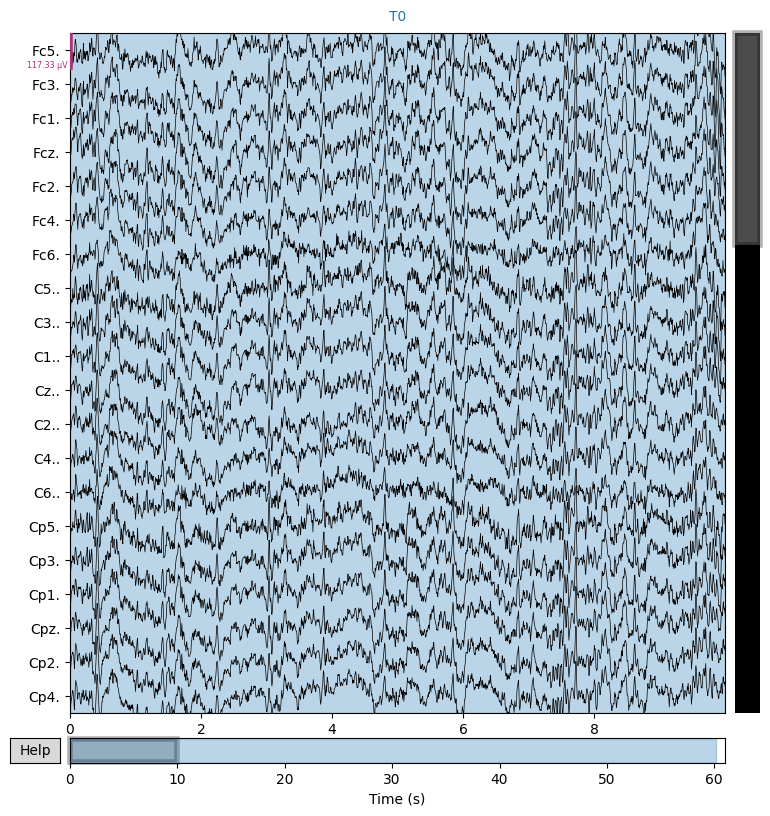

In [5]:
raw.plot(duration=10, n_channels=20, scalings="auto",
         title="Ham EEG — S001R01 (Dinlenme)")
plt.show()


## 3. Elektrot Yerleşimi (Montaj)

In [6]:
raw.rename_channels(lambda name: name.strip("."))

montage = mne.channels.make_standard_montage("standard_1005")
raw.set_montage(montage, on_missing="ignore")

print("Elektrot konumları atandı.")
print(f"İlk 5 kanal: {raw.ch_names[:5]}")


Elektrot konumları atandı.
İlk 5 kanal: ['Fc5', 'Fc3', 'Fc1', 'Fcz', 'Fc2']


## 4. Filtreleme (1–40 Hz)

In [7]:
raw_filtered = raw.copy().filter(
    l_freq=1.0,
    h_freq=40.0,
    method="fir",
    fir_design="firwin"
)
print("Filtre uygulandı: 1–40 Hz")


Filtre uygulandı: 1–40 Hz


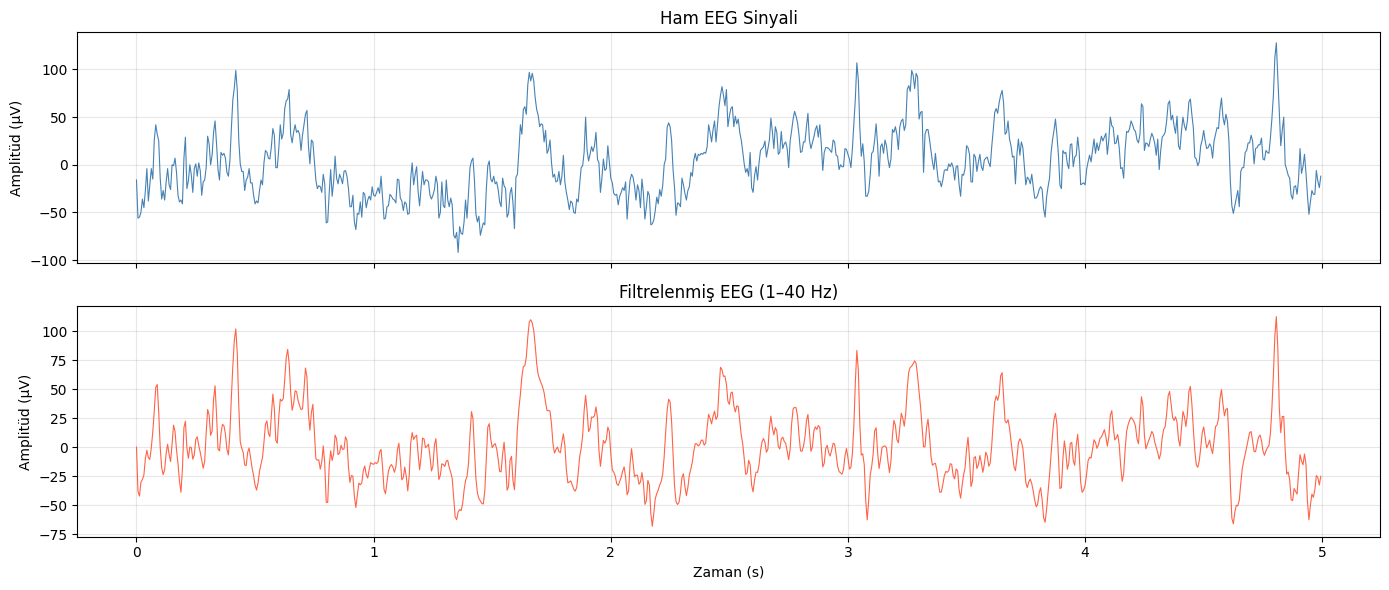

In [8]:
%matplotlib inline

n_samples = int(5 * raw.info["sfreq"])
times = raw.times[:n_samples]

raw_ch     = raw.get_data(picks=[0])[:, :n_samples][0] * 1e6        # V → μV
filtered_ch = raw_filtered.get_data(picks=[0])[:, :n_samples][0] * 1e6

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax1.plot(times, raw_ch, color="steelblue", linewidth=0.8)
ax1.set_title("Ham EEG Sinyali")
ax1.set_ylabel("Amplitüd (μV)")
ax1.grid(alpha=0.3)

ax2.plot(times, filtered_ch, color="tomato", linewidth=0.8)
ax2.set_title("Filtrelenmiş EEG (1–40 Hz)")
ax2.set_ylabel("Amplitüd (μV)")
ax2.set_xlabel("Zaman (s)")
ax2.grid(alpha=0.3)

plt.tight_layout()

OUT_DIR = os.path.join(os.path.expanduser("~"), "eeg_analysis", "outputs")
os.makedirs(OUT_DIR, exist_ok=True)
plt.savefig(os.path.join(OUT_DIR, "01_filtering.png"), dpi=150)
plt.show()


## 5. Güç Spektral Yoğunluğu (PSD) Analizi

EEG sinyali beş temel frekans bandına ayrılır:

| Band  | Aralık (Hz) | İlişkili durum                    |
|-------|-------------|-----------------------------------|
| Delta | 0.5 – 4     | Derin uyku                        |
| Theta | 4 – 8       | Uyuklama, meditasyon              |
| Alpha | 8 – 13      | Dinlenme, gözler kapalı           |
| Beta  | 13 – 30     | Aktif düşünme, konsantrasyon      |
| Gamma | 30 – 40     | Yüksek bilişsel aktivite          |


In [9]:
BANDS = {
    "Delta": (0.5,  4),
    "Theta": (4,    8),
    "Alpha": (8,   13),
    "Beta":  (13,  30),
    "Gamma": (30,  40),
}
BAND_COLORS = ["purple", "blue", "green", "orange", "red"]


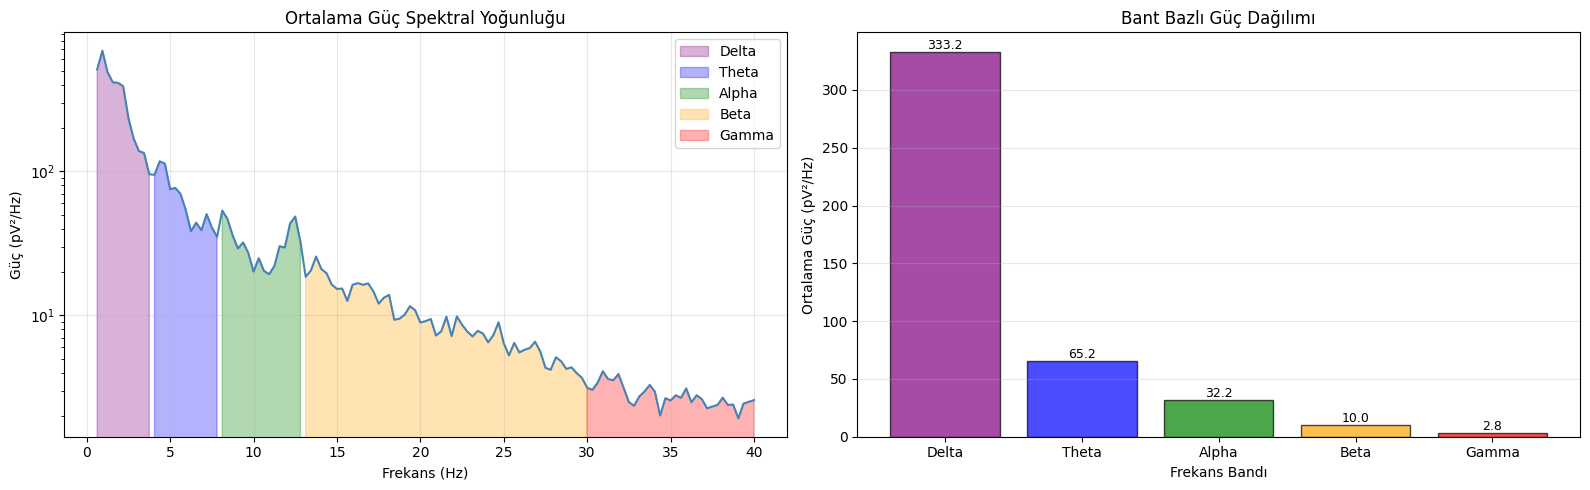

In [10]:
%matplotlib inline

# Welch yöntemiyle PSD hesaplama
spectrum = raw_filtered.compute_psd(method="welch", fmin=0.5, fmax=40, n_fft=512)
freqs = spectrum.freqs
psds  = spectrum.get_data()           # (n_kanallar, n_frekanslar)
mean_psd = psds.mean(axis=0) * 1e12  # V²/Hz → pV²/Hz

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# — Sol: ortalama PSD, bantlar renkli —
ax1.semilogy(freqs, mean_psd, color="steelblue", linewidth=1.5)
for (band, (lo, hi)), color in zip(BANDS.items(), BAND_COLORS):
    mask = (freqs >= lo) & (freqs <= hi)
    ax1.fill_between(freqs[mask], mean_psd[mask], alpha=0.3, color=color, label=band)
ax1.set_xlabel("Frekans (Hz)")
ax1.set_ylabel("Güç (pV²/Hz)")
ax1.set_title("Ortalama Güç Spektral Yoğunluğu")
ax1.legend()
ax1.grid(alpha=0.3)

# — Sağ: her bant için ortalama güç (çubuk grafik) —
band_powers = []
for band, (lo, hi) in BANDS.items():
    mask = (freqs >= lo) & (freqs <= hi)
    band_powers.append(psds[:, mask].mean() * 1e12)

bars = ax2.bar(list(BANDS), band_powers, color=BAND_COLORS, alpha=0.7, edgecolor="black")
ax2.set_xlabel("Frekans Bandı")
ax2.set_ylabel("Ortalama Güç (pV²/Hz)")
ax2.set_title("Bant Bazlı Güç Dağılımı")
ax2.grid(alpha=0.3, axis="y")

for bar, val in zip(bars, band_powers):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f"{val:.1f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "02_psd_analysis.png"), dpi=150)
plt.show()


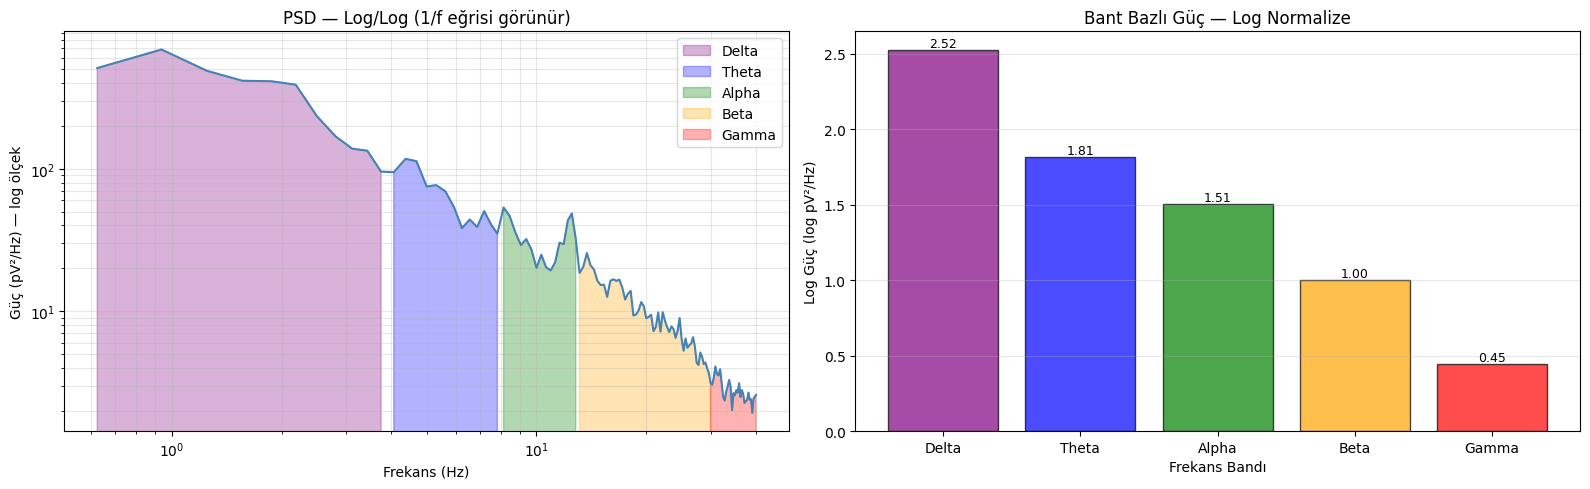

In [11]:
%matplotlib inline

# Log-log ölçeğinde PSD: 1/f gürültü eğrisi daha net görünür
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.loglog(freqs, mean_psd, color="steelblue", linewidth=1.5)
for (band, (lo, hi)), color in zip(BANDS.items(), BAND_COLORS):
    mask = (freqs >= lo) & (freqs <= hi)
    ax1.fill_between(freqs[mask], mean_psd[mask], alpha=0.3, color=color, label=band)
ax1.set_xlabel("Frekans (Hz)")
ax1.set_ylabel("Güç (pV²/Hz) — log ölçek")
ax1.set_title("PSD — Log/Log (1/f eğrisi görünür)")
ax1.legend()
ax1.grid(alpha=0.3, which="both")

# Log-normalize güç: Delta'nın diğer bantları ezip görselleştirmeyi bozmasını önler
log_powers = [
    np.log10(psds[:, (freqs >= lo) & (freqs <= hi)].mean() * 1e12)
    for _, (lo, hi) in BANDS.items()
]

bars = ax2.bar(list(BANDS), log_powers, color=BAND_COLORS, alpha=0.7, edgecolor="black")
ax2.set_xlabel("Frekans Bandı")
ax2.set_ylabel("Log Güç (log pV²/Hz)")
ax2.set_title("Bant Bazlı Güç — Log Normalize")
ax2.grid(alpha=0.3, axis="y")

for bar, val in zip(bars, log_powers):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f"{val:.2f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "02b_psd_normalized.png"), dpi=150)
plt.show()


## 6. Topografik Güç Haritaları

In [12]:
# Montajı sıfırla ve biosemi64 şemasıyla yeniden atama
raw_filtered.set_montage(None)
montage = mne.channels.make_standard_montage("biosemi64")
raw_filtered.set_montage(montage, on_missing="ignore", match_case=False)

print("Montaj güncellendi.")
print(f"Örnek kanal konumu: {raw_filtered.info['chs'][0]['loc'][:3]}")


Montaj güncellendi.
Örnek kanal konumu: [-0.08434934  0.03237868  0.06950535]


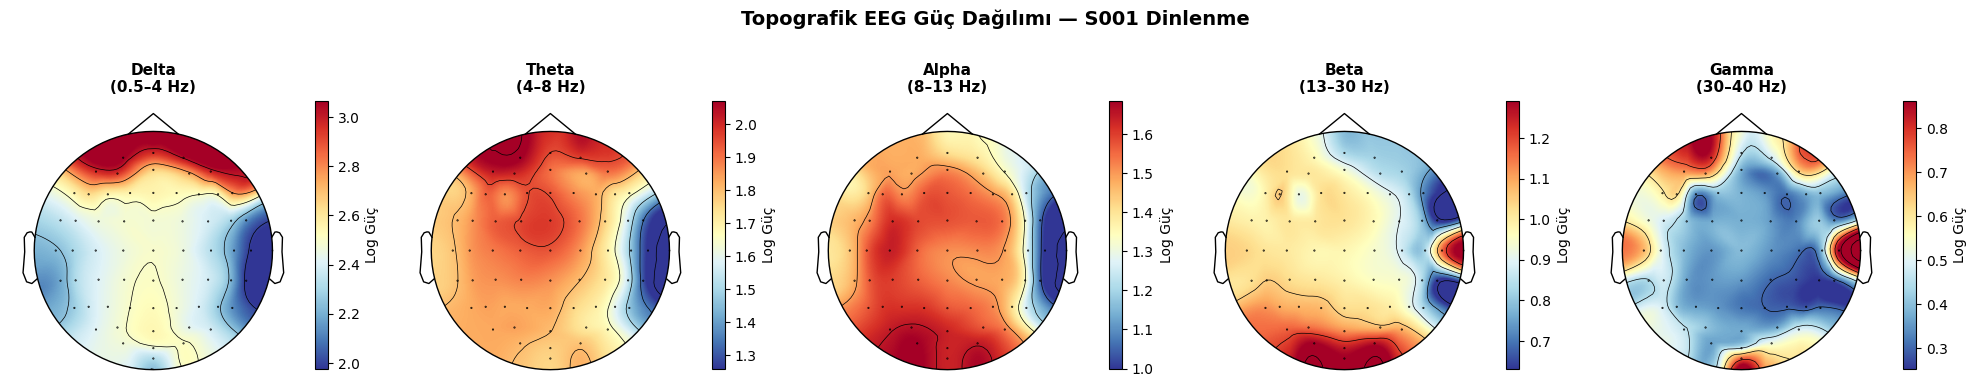

Topografik harita kaydedildi.


In [13]:
%matplotlib inline

# T9 ve T10 referans elektrotlarını dışla — topomap için konumları uygun değil
EXCLUDE = ["T9", "T10"]
exclude_idx = {raw_filtered.ch_names.index(ch)
               for ch in EXCLUDE if ch in raw_filtered.ch_names}
keep_idx = [i for i in range(len(raw_filtered.ch_names)) if i not in exclude_idx]

picks    = [ch for ch in raw_filtered.ch_names if ch not in EXCLUDE]
info_sub = mne.pick_info(raw_filtered.info, sel=keep_idx)

spectrum  = raw_filtered.compute_psd(method="welch", fmin=0.5, fmax=40, n_fft=512)
freqs     = spectrum.freqs
psds_sub  = spectrum.get_data()[keep_idx, :]

fig, axes = plt.subplots(1, len(BANDS), figsize=(20, 4))

for ax, (band, (lo, hi)), color in zip(axes, BANDS.items(), BAND_COLORS):
    mask       = (freqs >= lo) & (freqs <= hi)
    band_power = np.log10(psds_sub[:, mask].mean(axis=1) * 1e12)

    im, _ = mne.viz.plot_topomap(
        band_power, info_sub,
        axes=ax, show=False,
        cmap="RdYlBu_r",
        vlim=(band_power.min(), band_power.max()),
        extrapolate="head"
    )
    ax.set_title(f"{band}\n({lo}–{hi} Hz)", fontsize=11, fontweight="bold")
    plt.colorbar(im, ax=ax, shrink=0.8, label="Log Güç")

fig.suptitle("Topografik EEG Güç Dağılımı — S001 Dinlenme",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "03_topomap.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Topografik harita kaydedildi.")
